<div align="center">

# <span style="color:#2C3E50;">Urban Flood Mapping Using Satellite SAR Data</span>
## <span style="color:#34495E;">Final Approach — Physics-Guided UNet++ with Compound Loss</span>

</div>

This notebook is the **final consolidated approach**, combining the most effective elements from all prior experiments:

| Component | Source | Rationale |
|-----------|--------|-----------|
| **UNet++ + EfficientNet-B4 + SCSE** | Approaches 1 & 4 | Battle-tested SMP stack; stable, no custom recurrent modules |
| **Physics double-bounce penalty** | Approach 5 | Encodes electromagnetic dihedral physics; attacks the hard Flooded-Urban class directly |
| **Soft Dice Loss** | New | Directly optimises boundary overlap; WCE alone is insensitive to boundary precision |
| **Physics warmup schedule** | New | Prevents early-epoch loss collapse when the physics mask fires on uninitialised logits |
| **4× FU oversampling + class weights** | All approaches | Corrects the severe Flooded-Urban class imbalance |
| **Gradient clipping + AMP** | Standard | Prevents gradient explosions during the combined loss backward pass |
| **Checkpoint on Urban F1** | New | Saves the model that actually matters for the application metric |

### Three-term loss
$$L_{total} = L_{WCE} + \lambda_{dice} \cdot L_{Dice} + \lambda_{phys}(e) \cdot L_{physics}$$

where $\lambda_{phys}(e)$ is linearly changed from 0 to its target over epochs 5–20, preventing premature penalisation of uninitialised predictions.

---

<div align="center">

## <span style="color:#16A085;">Project Information</span>

</div>

| **Field**       | **Details**                                    |
|-----------------|------------------------------------------------|
| **Course**      | Deep Learning Project                          |
| **Deliverable** | Deliverable 3 – Final Consolidated Model       |
| **Authors**     | Muhammad Sharjeel Nawaz & Syed Moiz Ejaz       |
| **Roll Numbers**| 28100321 & 28100357                            |
| **Approach**    | Final — Physics-Guided UNet++ Compound Loss    |


## <span style="color:#3498DB;">0. Installation</span>

In [1]:
!pip install -q segmentation-models-pytorch albumentations tifffile tqdm matplotlib rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.8 MB/s eta 0:00:00


## <span style="color:#3498DB;">1. Imports</span>

In [2]:
import os
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print(f'PyTorch     : {torch.__version__}')
print(f'CUDA        : {torch.cuda.is_available()}')
print(f'SMP         : {smp.__version__}')
if torch.cuda.is_available():
    print(f'GPU         : {torch.cuda.get_device_name(0)}')
    print(f'VRAM        : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PyTorch     : 2.10.0+cu128
CUDA        : True
SMP         : 0.5.0
GPU         : Tesla T4
VRAM        : 15.6 GB


In [ ]:
device      = 'cuda' if torch.cuda.is_available() else 'cpu'
def find_dataset_root(search_root='/kaggle/input', split_file='Train_dataset.txt'):
    for dirpath, _, filenames in os.walk(search_root):
        if split_file in filenames:
            return dirpath
    return None

path = find_dataset_root()
if path is None:
    path = '/kaggle/input/datasets/hritik05/urbansarflood-dataset/train_validation'
    print(f'WARN: auto-discovery failed, using fallback: {path}')
else:
    print(f'Dataset root: {path}')

batch_size  = 8 
num_workers = 4
epochs      = 50
imgsize     = 256
in_channels = 8
num_classes = 3
fu_repeat   = 4
lr          = 3e-4
weight_decay= 1e-4
grad_clip   = 1.0
warmup_epochs = 3

class_weights     = torch.tensor([0.15, 0.35, 0.50], device=device)
lambda_dice       = 0.5
lambda_phys_max   = 0.8
phys_warmup_start = 5
phys_warmup_end   = 20
PRE_VH_IDX      = 4
PRE_VV_IDX      = 5
DUR_VH_IDX      = 6
DUR_VV_IDX      = 7
delta_thresh    = 0.25
specular_thresh = 0.15
exp_scale       = 4.0 

classes_name = ['Non-Flooded', 'Flooded Open', 'Flooded Urban']
PALETTE      = [(50, 50, 50), (30, 144, 255), (255, 100, 0)]

print(f'Device      : {device}')
print(f'Batch size  : {batch_size}')
print(f'Epochs      : {epochs}')
print(f'Loss        : WCE + {lambda_dice}·Dice + (0→{lambda_phys_max})·Physics')

Dataset root: /kaggle/input/datasets/hritik05/urbansarflood-dataset/train_validation
Device      : cuda
Batch size  : 8
Epochs      : 50
Loss        : WCE + 0.5·Dice + (0→0.8)·Physics


In [ ]:
class UrbanSARDataset(Dataset):
    def __init__(self, dataset_root, split_file, transform=None, fu_repeat=4):
        self.transform   = transform
        self.image_paths = []
        self.mask_paths  = []

        split_path = os.path.join(dataset_root, split_file)
        if not os.path.exists(split_path):
            raise FileNotFoundError(f'Split file not found: {split_path}')

        with open(split_path, 'r') as f:
            for line in f:
                raw = line.strip()
                if not raw:
                    continue
                parts      = raw.split('/')
                clean_base = os.path.join(*parts[-3:])

                if 'GT' in clean_base:
                    gt_rel  = clean_base
                    sar_rel = clean_base.replace('GT', 'SAR')
                else:
                    sar_rel = clean_base
                    gt_rel  = clean_base.replace('SAR', 'GT')

                sar_full = os.path.join(dataset_root, sar_rel)
                gt_full  = os.path.join(dataset_root, gt_rel)
                n = fu_repeat if ('Train' in split_file and '03_FU' in clean_base) else 1
                for _ in range(n):
                    self.image_paths.append(sar_full)
                    self.mask_paths.append(gt_full)
    @staticmethod
    def _normalise(image_hwc: np.ndarray) -> np.ndarray:
        out = image_hwc.copy()
        for c in range(out.shape[2]):
            c_min, c_max = out[:, :, c].min(), out[:, :, c].max()
            if c_max > c_min:
                out[:, :, c] = (out[:, :, c] - c_min) / (c_max - c_min)
            else:
                out[:, :, c] = 0.0
        return out
    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        with rasterio.open(self.image_paths[index]) as src:
            image = src.read().astype(np.float32)
        with rasterio.open(self.mask_paths[index]) as src:
            mask  = src.read(1).astype(np.int64)
        mask = np.clip(mask, 0, num_classes - 1)
        image = np.transpose(image, (1, 2, 0))
        image = self._normalise(image)

        if self.transform:
            aug   = self.transform(image=image, mask=mask)
            image = aug['image']
            mask  = aug['mask']
        image = torch.from_numpy(np.transpose(image, (2, 0, 1)).copy()).float()
        mask  = torch.from_numpy(np.array(mask).copy()).long()
        return image, mask

In [ ]:
train_transform = A.Compose([
    A.RandomCrop(height=imgsize, width=imgsize),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.GaussNoise(var_limit=(0.0, 0.005), p=0.4),
    A.CoarseDropout(
        max_holes=8, max_height=16, max_width=16,
        min_holes=1, min_height=4,  min_width=4,
        fill_value=0, p=0.3
    ),
])

val_transform = A.Compose([
    A.CenterCrop(height=imgsize, width=imgsize),
])

try:
    train_dataset = UrbanSARDataset(path, 'Train_dataset.txt',
                                    transform=train_transform, fu_repeat=fu_repeat)
    val_dataset   = UrbanSARDataset(path, 'Valid_dataset.txt',
                                    transform=val_transform,   fu_repeat=1)
except FileNotFoundError as e:
    print(f'[ERROR] {e}')
    raise

train_loader = DataLoader(train_dataset, batch_size=batch_size,
                          shuffle=True,  num_workers=num_workers, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size,
                          shuffle=False, num_workers=num_workers, pin_memory=True)

print(f'Train samples : {len(train_dataset)}')
print(f'Val   samples : {len(val_dataset)}')
print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')

img0, msk0 = train_dataset[0]
print(f'\nSample image : shape={tuple(img0.shape)}, dtype={img0.dtype}, range=[{img0.min():.3f}, {img0.max():.3f}]')
print(f'Sample mask  : shape={tuple(msk0.shape)}, dtype={msk0.dtype}, unique={torch.unique(msk0).tolist()}')

Train samples : 5914
Val   samples : 1970
Train batches : 740
Val   batches : 247

Sample image : shape=(8, 256, 256), dtype=torch.float32, range=[0.000, 1.000]
Sample mask  : shape=(256, 256), dtype=torch.int64, unique=[0]


## <span style="color:#3498DB;">4. Model Architecture — UNet++ with EfficientNet-B4</span>

We employ a **U‑Net** with a **ResNet50 encoder** pre‑trained on ImageNet. The encoder extracts multi‑scale features, while the decoder reconstructs the segmentation mask.

```python
smp.UnetPlusPlus(
    encoder_name="efficientnet-b4",
    encoder_weights="imagenet",
    in_channels=in_channels,
    classes=num_classes,
    decoder_attention_type="scse"

In [ ]:
model = smp.UnetPlusPlus(
    encoder_name        = 'efficientnet-b4',
    encoder_weights     = 'imagenet',
    in_channels         = in_channels,
    classes             = num_classes,
    decoder_attention_type = 'scse',
).to(device)

n_params     = sum(p.numel() for p in model.parameters())
n_trainable  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {n_params:,}')
print(f'Trainable params: {n_trainable:,}')

with torch.no_grad():
    dummy  = torch.zeros(2, in_channels, imgsize, imgsize, device=device)
    out    = model(dummy)
    print(f'Output shape    : {tuple(out.shape)}')   # should be (2, 3, 256, 256)
    assert out.shape == (2, num_classes, imgsize, imgsize), 'Shape mismatch!'
    print('Forward pass    : OK')
del dummy, out

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Total params    : 20,926,878
Trainable params: 20,926,878
Output shape    : (2, 3, 256, 256)
Forward pass    : OK


## <span style="color:#3498DB;">5. Loss Function — Physics-Guided Compound Loss</span>

### Three terms

**1. Weighted Cross-Entropy with weights`[0.15, 0.35, 0.50]`**.

**2. Soft Dice Loss** 

**3. Physics Double-Bounce Penalty** 


In [ ]:
class SoftDiceLoss(nn.Module):
    def __init__(self, smooth: float = 1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        probs   = F.softmax(logits, dim=1)
        B, C, H, W = probs.shape
        one_hot = torch.zeros_like(probs)
        one_hot.scatter_(1, targets.unsqueeze(1), 1.0)
        probs_f   = probs.view(B, C, -1)
        targets_f = one_hot.view(B, C, -1)
        intersection = (probs_f * targets_f).sum(dim=2)
        cardinality  = probs_f.sum(dim=2) + targets_f.sum(dim=2) 
        dice_per_class = (2.0 * intersection + self.smooth) / (cardinality + self.smooth)
        return 1.0 - dice_per_class.mean()

In [ ]:
class PhysicsGuidedCompoundLoss(nn.Module):
    def __init__(
        self,
        class_weights:     torch.Tensor,
        lambda_dice:       float = 0.5,
        lambda_phys_max:   float = 0.8,
        phys_warmup_start: int   = 5,
        phys_warmup_end:   int   = 20,
        pre_vh_idx:        int   = 4,
        pre_vv_idx:        int   = 5,
        dur_vh_idx:        int   = 6,
        dur_vv_idx:        int   = 7,
        delta_thresh:      float = 0.25,
        specular_thresh:   float = 0.15,
        exp_scale:         float = 4.0,
    ):
        super().__init__()
        self.wce               = nn.CrossEntropyLoss(weight=class_weights)
        self.dice              = SoftDiceLoss()
        self.lambda_dice       = lambda_dice
        self.lambda_phys_max   = lambda_phys_max
        self.phys_warmup_start = phys_warmup_start
        self.phys_warmup_end   = phys_warmup_end
        self.pre_vh_idx        = pre_vh_idx
        self.pre_vv_idx        = pre_vv_idx
        self.dur_vh_idx        = dur_vh_idx
        self.dur_vv_idx        = dur_vv_idx
        self.delta_thresh      = delta_thresh
        self.specular_thresh   = specular_thresh
        self.exp_scale         = exp_scale

    def get_lambda_phys(self, epoch: int) -> float:
        if epoch < self.phys_warmup_start:
            return 0.0
        if epoch >= self.phys_warmup_end:
            return self.lambda_phys_max
        t = (epoch - self.phys_warmup_start) / (self.phys_warmup_end - self.phys_warmup_start)
        return float(t * self.lambda_phys_max)

    @torch.no_grad()
    def _double_bounce_mask(self, images: torch.Tensor) -> torch.Tensor:
        pre_vh = images[:, self.pre_vh_idx]   # (B, H, W)
        pre_vv = images[:, self.pre_vv_idx]
        dur_vh = images[:, self.dur_vh_idx]
        dur_vv = images[:, self.dur_vv_idx]
        delta_vh  = dur_vh - pre_vh
        delta_vv  = dur_vv - pre_vv
        delta_max = torch.maximum(delta_vh, delta_vv)
        cond_increase = (delta_max > self.delta_thresh).float()
        specular_pix  = (dur_vv < self.specular_thresh).float()
        specular_neigh = F.max_pool2d(
            specular_pix.unsqueeze(1), kernel_size=3, stride=1, padding=1
        ).squeeze(1)

        return cond_increase * specular_neigh
    def forward(
        self,
        logits: torch.Tensor,
        masks:  torch.Tensor,
        images: torch.Tensor,
        epoch:  int,
    ):

        l_wce  = self.wce(logits, masks)
        l_dice = self.dice(logits, masks)
        lambda_phys = self.get_lambda_phys(epoch)
        if lambda_phys > 0.0:
            db_mask    = self._double_bounce_mask(images)
            prob       = F.softmax(logits, dim=1)
            p_nf       = prob[:, 0]
            denom      = db_mask.sum().clamp(min=1.0)
            l_phys     = (penalty * db_mask).sum() / denom
        else:
            l_phys     = torch.tensor(0.0, device=logits.device)
            lambda_phys = 0.0

        l_total = l_wce + self.lambda_dice * l_dice + lambda_phys * l_phys

        return l_total, l_wce.detach(), l_dice.detach(), l_phys.detach()

In [ ]:
loss_fn = PhysicsGuidedCompoundLoss(
    class_weights     = class_weights,
    lambda_dice       = lambda_dice,
    lambda_phys_max   = lambda_phys_max,
    phys_warmup_start = phys_warmup_start,
    phys_warmup_end   = phys_warmup_end,
    pre_vh_idx        = PRE_VH_IDX,
    pre_vv_idx        = PRE_VV_IDX,
    dur_vh_idx        = DUR_VH_IDX,
    dur_vv_idx        = DUR_VV_IDX,
    delta_thresh      = delta_thresh,
    specular_thresh   = specular_thresh,
    exp_scale         = exp_scale,
)
_imgs, _msks = next(iter(val_loader))
_imgs_d      = _imgs.to(device)
_db          = loss_fn._double_bounce_mask(_imgs_d)
_fu_pixels   = (_msks == 2).sum().item()
_db_pixels   = _db.sum().item()
print(f'Double-bounce candidates : {_db_pixels:.0f} px / batch')
print(f'Flooded-Urban pixels     : {_fu_pixels:.0f} px / batch')
print(f'Mask coverage            : {100*_db_pixels/(_db.numel()+1e-6):.2f}%')
if _db_pixels < 100:
    print('WARN: Very few physics candidates — consider lowering delta_thresh slightly.')
del _imgs_d, _db, _imgs, _msks

Double-bounce candidates : 1 px / batch
Flooded-Urban pixels     : 1567 px / batch
Mask coverage            : 0.00%
WARN: Very few physics candidates — consider lowering delta_thresh slightly.


In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=lr,
    weight_decay=weight_decay,
)

def lr_lambda(epoch):
    """Linear warmup for warmup_epochs, then cosine decay."""
    if epoch < warmup_epochs:
        return float(epoch + 1) / float(warmup_epochs)
    progress = (epoch - warmup_epochs) / max(1, epochs - warmup_epochs)
    return 0.01 + 0.5 * (1.0 - 0.01) * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
scaler = torch.amp.GradScaler('cuda') if device == 'cuda' else None

print('Optimiser : AdamW')
print(f'Scheduler : linear warmup ({warmup_epochs} ep) → cosine annealing')
print(f'AMP Scaler: {scaler is not None}')

Optimiser : AdamW
Scheduler : linear warmup (3 ep) → cosine annealing
AMP Scaler: True


## <span style="color:#3498DB;">7. Metrics</span>

In [ ]:
def compute_metrics(logits: torch.Tensor, targets: torch.Tensor, n_classes: int):
    preds   = torch.argmax(logits, dim=1).view(-1)
    targets = targets.view(-1)
    ious, f1s = [], []

    for cls in range(n_classes):
        pred_c   = (preds == cls)
        target_c = (targets == cls)
        inter    = (pred_c & target_c).sum().float()
        union    = pred_c.sum() + target_c.sum() - inter
        denom_f1 = pred_c.sum() + target_c.sum()

        ious.append((inter / union).item() if union > 0 else float('nan'))
        f1s.append(((2.0 * inter) / denom_f1).item() if denom_f1 > 0 else float('nan'))

    return ious, f1s

## <span style="color:#3498DB;">8. Training Loop</span>


In [12]:
# ─── History buffers ─────────────────────────────────────────────────────────
history = {
    'train_loss':  [], 'val_loss':    [],
    'l_wce':       [], 'l_dice':      [], 'l_phys':   [],
    'miou':        [], 'mf1':         [],
    'iou_nf':      [], 'iou_fo':      [], 'iou_fu':   [],
    'f1_nf':       [], 'f1_fo':       [], 'f1_fu':    [],
    'lr':          [], 'lambda_phys': [],
}

best_urban_f1  = -1.0
best_val_loss  = float('inf')
ckpt_urban     = 'best_urban_f1.pth'
ckpt_loss      = 'best_val_loss.pth'

print('Training started\n' + '═'*80)

Training started
════════════════════════════════════════════════════════════════════════════════


In [ ]:
for epoch in range(epochs):
    ep_display = epoch + 1

    lp_now = loss_fn.get_lambda_phys(epoch)
    history['lambda_phys'].append(lp_now)
    model.train()
    t_loss = t_wce = t_dice = t_phys = 0.0
    n_batches = 0

    train_bar = tqdm(train_loader,
                     desc=f'Ep {ep_display:03d}/{epochs} [Train]',
                     leave=False)

    for images, masks in train_bar:
        images = images.to(device, non_blocking=True)
        masks  = masks.to(device,  non_blocking=True)

        optimizer.zero_grad()

        if scaler is not None:
            with torch.amp.autocast('cuda'):
                logits = model(images)
                loss, lw, ld, lph = loss_fn(logits, masks, images, epoch)

            # NaN guard
            if not torch.isfinite(loss):
                print(f'  [WARN] Non-finite loss at ep {ep_display}, batch skipped')
                continue

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()

        else:
            logits = model(images)
            loss, lw, ld, lph = loss_fn(logits, masks, images, epoch)

            if not torch.isfinite(loss):
                print(f'  [WARN] Non-finite loss at ep {ep_display}, batch skipped')
                continue

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

        t_loss += loss.item()
        t_wce  += lw.item()
        t_dice += ld.item()
        t_phys += lph.item()
        n_batches += 1

        train_bar.set_postfix(loss=f'{loss.item():.4f}',
                              lp=f'{lp_now:.2f}')

    scheduler.step()

    avg_t = t_loss  / max(n_batches, 1)
    avg_w = t_wce   / max(n_batches, 1)
    avg_d = t_dice  / max(n_batches, 1)
    avg_p = t_phys  / max(n_batches, 1)
    cur_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(avg_t)
    history['l_wce'].append(avg_w)
    history['l_dice'].append(avg_d)
    history['l_phys'].append(avg_p)
    history['lr'].append(cur_lr)

    model.eval()
    v_loss = 0.0
    all_ious, all_f1s = [], []

    val_bar = tqdm(val_loader,
                   desc=f'Ep {ep_display:03d}/{epochs} [Val]  ',
                   leave=False)

    with torch.no_grad():
        for images, masks in val_bar:
            images = images.to(device, non_blocking=True)
            masks  = masks.to(device,  non_blocking=True)

            if scaler is not None:
                with torch.amp.autocast('cuda'):
                    logits = model(images)
                    loss, _, _, _ = loss_fn(logits, masks, images, epoch)
            else:
                logits = model(images)
                loss, _, _, _ = loss_fn(logits, masks, images, epoch)

            v_loss += loss.item()
            b_ious, b_f1s = compute_metrics(logits, masks, num_classes)
            all_ious.append(b_ious)
            all_f1s.append(b_f1s)

    avg_v    = v_loss / len(val_loader)
    ep_ious  = np.nanmean(np.array(all_ious), axis=0)
    ep_f1s   = np.nanmean(np.array(all_f1s),  axis=0)
    miou     = float(np.nanmean(ep_ious))
    mf1      = float(np.nanmean(ep_f1s))
    urban_f1 = float(ep_f1s[2])
    history['val_loss'].append(avg_v)
    history['miou'].append(miou)
    history['mf1'].append(mf1)
    history['iou_nf'].append(float(ep_ious[0]))
    history['iou_fo'].append(float(ep_ious[1]))
    history['iou_fu'].append(float(ep_ious[2]))
    history['f1_nf'].append(float(ep_f1s[0]))
    history['f1_fo'].append(float(ep_f1s[1]))
    history['f1_fu'].append(float(ep_f1s[2]))

    if urban_f1 > best_urban_f1:
        best_urban_f1 = urban_f1
        torch.save(model.state_dict(), ckpt_urban)
        tag_u = '★'
    else:
        tag_u = ' '

    if avg_v < best_val_loss:
        best_val_loss = avg_v
        torch.save(model.state_dict(), ckpt_loss)
        tag_l = '●'
    else:
        tag_l = ' '
    print(
        f'Ep {ep_display:03d}/{epochs} {tag_u}{tag_l} | '
        f'TrLoss={avg_t:.4f} '
        f'(WCE={avg_w:.3f} Dice={avg_d:.3f} Phys={avg_p:.3f} lp={lp_now:.2f}) | '
        f'ValLoss={avg_v:.4f} | '
        f'mIoU={miou:.4f} mF1={mf1:.4f} | '
        f'FU_F1={urban_f1:.4f} | '
        f'lr={cur_lr:.2e}'
    )
torch.save(model.state_dict(), 'final_model.pth')
print('\n' + '═'*80)
print(f'Training complete.')
print(f'Best Urban F1  : {best_urban_f1:.4f}  → {ckpt_urban}')
print(f'Best Val Loss  : {best_val_loss:.4f}  → {ckpt_loss}')

Ep 001/50 ★● | TrLoss=0.7483 (WCE=0.396 Dice=0.705 Phys=0.000 lp=0.00) | ValLoss=0.4277 | mIoU=0.3555 mF1=0.3708 | FU_F1=0.0000 | lr=2.00e-04


Ep 002/50  ● | TrLoss=0.4469 (WCE=0.123 Dice=0.647 Phys=0.000 lp=0.00) | ValLoss=0.3810 | mIoU=0.4111 mF1=0.4400 | FU_F1=0.0000 | lr=3.00e-04


Ep 003/50  ● | TrLoss=0.4284 (WCE=0.108 Dice=0.640 Phys=0.000 lp=0.00) | ValLoss=0.3769 | mIoU=0.3899 mF1=0.4117 | FU_F1=0.0000 | lr=3.00e-04


Ep 004/50 ★● | TrLoss=0.4157 (WCE=0.098 Dice=0.636 Phys=0.000 lp=0.00) | ValLoss=0.3756 | mIoU=0.4036 mF1=0.4327 | FU_F1=0.0404 | lr=3.00e-04


Ep 005/50 ★● | TrLoss=0.4071 (WCE=0.091 Dice=0.633 Phys=0.000 lp=0.00) | ValLoss=0.3717 | mIoU=0.3939 mF1=0.4193 | FU_F1=0.0499 | lr=2.99e-04


...

Ep 046/50    | TrLoss=1.0278 (WCE=0.534 Dice=0.665 Phys=0.202 lp=0.80) | ValLoss=9.2634 | mIoU=0.3899 mF1=0.4077 | FU_F1=0.0254 | lr=8.28e-06


Ep 047/50    | TrLoss=1.0300 (WCE=0.532 Dice=0.666 Phys=0.207 lp=0.80) | ValLoss=7.9445 | mIoU=0.3890 mF1=0.4066 | FU_F1=0.0253 | lr=5.98e-06


Ep 048/50    | TrLoss=1.0214 (WCE=0.525 Dice=0.664 Phys=0.206 lp=0.80) | ValLoss=5.5928 | mIoU=0.3877 mF1=0.4051 | FU_F1=0.0251 | lr=4.32e-06


Ep 049/50    | TrLoss=1.0259 (WCE=0.529 Dice=0.665 Phys=0.205 lp=0.80) | ValLoss=5.4814 | mIoU=0.3869 mF1=0.4043 | FU_F1=0.0250 | lr=3.33e-06


Ep 050/50    | TrLoss=1.0232 (WCE=0.527 Dice=0.665 Phys=0.204 lp=0.80) | ValLoss=8.8526 | mIoU=0.3900 mF1=0.4077 | FU_F1=0.0251 | lr=3.00e-06

════════════════════════════════════════════════════════════════════════════════
Training complete.
Best Urban F1  : 0.0864  → best_urban_f1.pth
Best Val Loss  : 0.3717  → best_val_loss.pth


## <span style="color:#3498DB;">9. Training Curves</span>

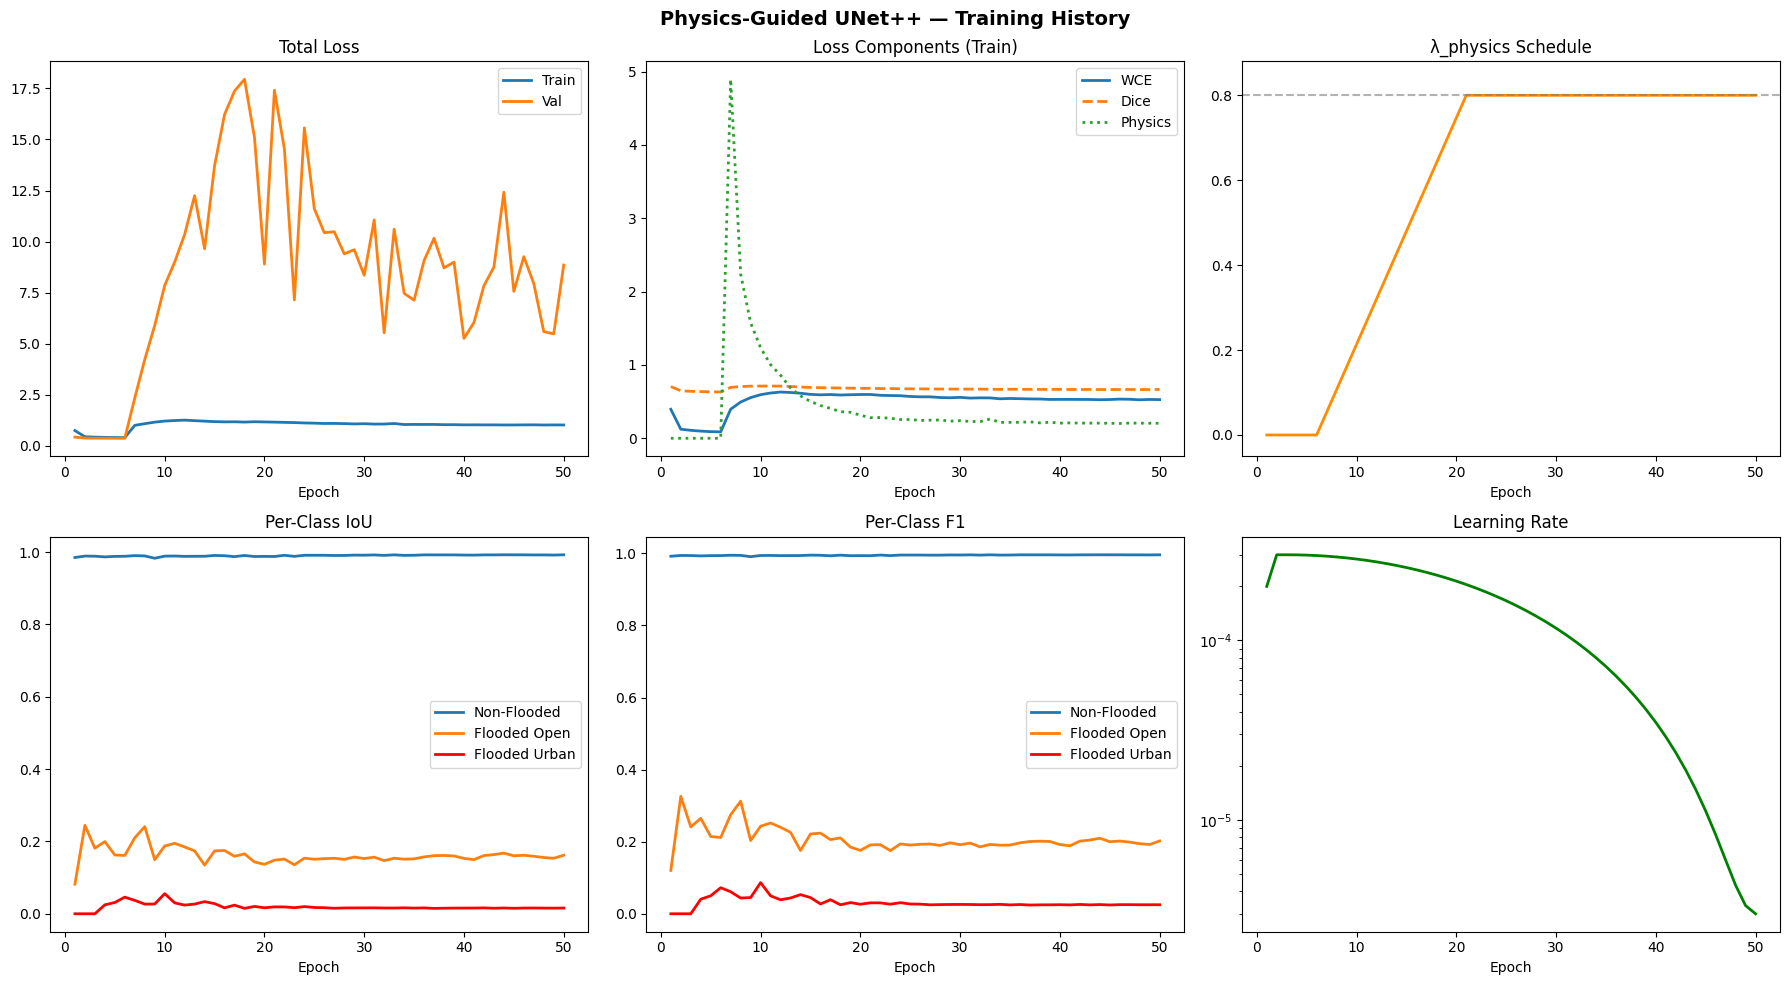

Saved → training_curves.png


In [ ]:
ep_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Physics-Guided UNet++ — Training History', fontsize=14, fontweight='bold')

ax = axes[0, 0]
ax.plot(ep_range, history['train_loss'], label='Train', linewidth=2)
ax.plot(ep_range, history['val_loss'],   label='Val',   linewidth=2)
ax.set_title('Total Loss'); ax.set_xlabel('Epoch'); ax.legend()

ax = axes[0, 1]
ax.plot(ep_range, history['l_wce'],  label='WCE',    linewidth=2)
ax.plot(ep_range, history['l_dice'], label='Dice',   linewidth=2, linestyle='--')
ax.plot(ep_range, history['l_phys'], label='Physics',linewidth=2, linestyle=':')
ax.set_title('Loss Components (Train)'); ax.set_xlabel('Epoch'); ax.legend()

ax = axes[0, 2]
ax.plot(ep_range, history['lambda_phys'], color='darkorange', linewidth=2)
ax.axhline(lambda_phys_max, linestyle='--', color='gray', alpha=0.6)
ax.set_title('λ_physics Schedule'); ax.set_xlabel('Epoch')
ax.set_ylim(-0.05, lambda_phys_max * 1.1)

ax = axes[1, 0]
ax.plot(ep_range, history['iou_nf'], label='Non-Flooded', linewidth=2)
ax.plot(ep_range, history['iou_fo'], label='Flooded Open', linewidth=2)
ax.plot(ep_range, history['iou_fu'], label='Flooded Urban', linewidth=2, color='red')
ax.set_title('Per-Class IoU'); ax.set_xlabel('Epoch'); ax.legend()

ax = axes[1, 1]
ax.plot(ep_range, history['f1_nf'], label='Non-Flooded', linewidth=2)
ax.plot(ep_range, history['f1_fo'], label='Flooded Open', linewidth=2)
ax.plot(ep_range, history['f1_fu'], label='Flooded Urban', linewidth=2, color='red')
ax.set_title('Per-Class F1'); ax.set_xlabel('Epoch'); ax.legend()
ax = axes[1, 2]
ax.semilogy(ep_range, history['lr'], color='green', linewidth=2)
ax.set_title('Learning Rate'); ax.set_xlabel('Epoch')

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → training_curves.png')

## <span style="color:#3498DB;">10. Evaluation on Validation Set</span>


In [ ]:
print('Loading best Urban-F1 checkpoint...')
model.load_state_dict(torch.load(ckpt_urban, map_location=device))
model.eval()

all_ious, all_f1s = [], []
conf_mat = np.zeros((num_classes, num_classes), dtype=np.int64)

with torch.no_grad():
    for images, masks in tqdm(val_loader, desc='Final evaluation'):
        images = images.to(device, non_blocking=True)
        masks  = masks.to(device,  non_blocking=True)

        if scaler is not None:
            with torch.amp.autocast('cuda'):
                logits = model(images)
        else:
            logits = model(images)

        b_ious, b_f1s = compute_metrics(logits, masks, num_classes)
        all_ious.append(b_ious)
        all_f1s.append(b_f1s)

        preds_flat  = torch.argmax(logits, dim=1).view(-1).cpu().numpy()
        masks_flat  = masks.view(-1).cpu().numpy()
        for pred_c, true_c in zip(preds_flat, masks_flat):
            conf_mat[true_c, pred_c] += 1

final_ious = np.nanmean(np.array(all_ious), axis=0)
final_f1s  = np.nanmean(np.array(all_f1s),  axis=0)
final_miou = float(np.nanmean(final_ious))
final_mf1  = float(np.nanmean(final_f1s))

print('\n' + '═'*60)
print(f'  Final Results  (best Urban-F1 checkpoint)')
print('═'*60)
print(f'  mIoU         : {final_miou:.4f}')
print(f'  mF1          : {final_mf1:.4f}')
print('─'*60)
for i, name in enumerate(classes_name):
    print(f'  [{name:15s}]  IoU={final_ious[i]:.4f}   F1={final_f1s[i]:.4f}')
print('═'*60)

Loading best Urban-F1 checkpoint...


Final evaluation: 100%|██████████| 247/247 [02:11<00:00,  1.88it/s]


════════════════════════════════════════════════════════════
  Final Results  (best Urban-F1 checkpoint)
════════════════════════════════════════════════════════════
  mIoU         : 0.4105
  mF1          : 0.4412
────────────────────────────────────────────────────────────
  [Non-Flooded    ]  IoU=0.9886   F1=0.9941
  [Flooded Open   ]  IoU=0.1874   F1=0.2430
  [Flooded Urban  ]  IoU=0.0556   F1=0.0864
════════════════════════════════════════════════════════════


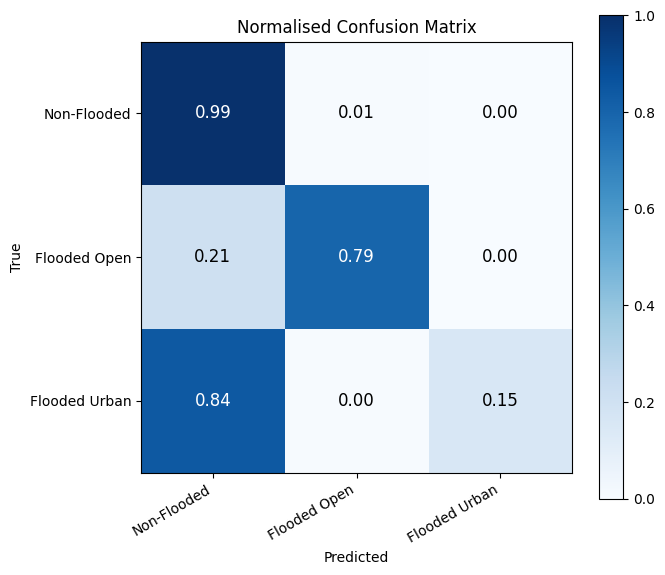

Saved → confusion_matrix.png


In [ ]:
conf_norm = conf_mat.astype(float) / conf_mat.sum(axis=1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(conf_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(classes_name, rotation=30, ha='right')
ax.set_yticklabels(classes_name)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Normalised Confusion Matrix')

for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, f'{conf_norm[i, j]:.2f}',
                ha='center', va='center',
                color='white' if conf_norm[i, j] > 0.6 else 'black',
                fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → confusion_matrix.png')

## <span style="color:#3498DB;">11. Qualitative Visualisation</span>

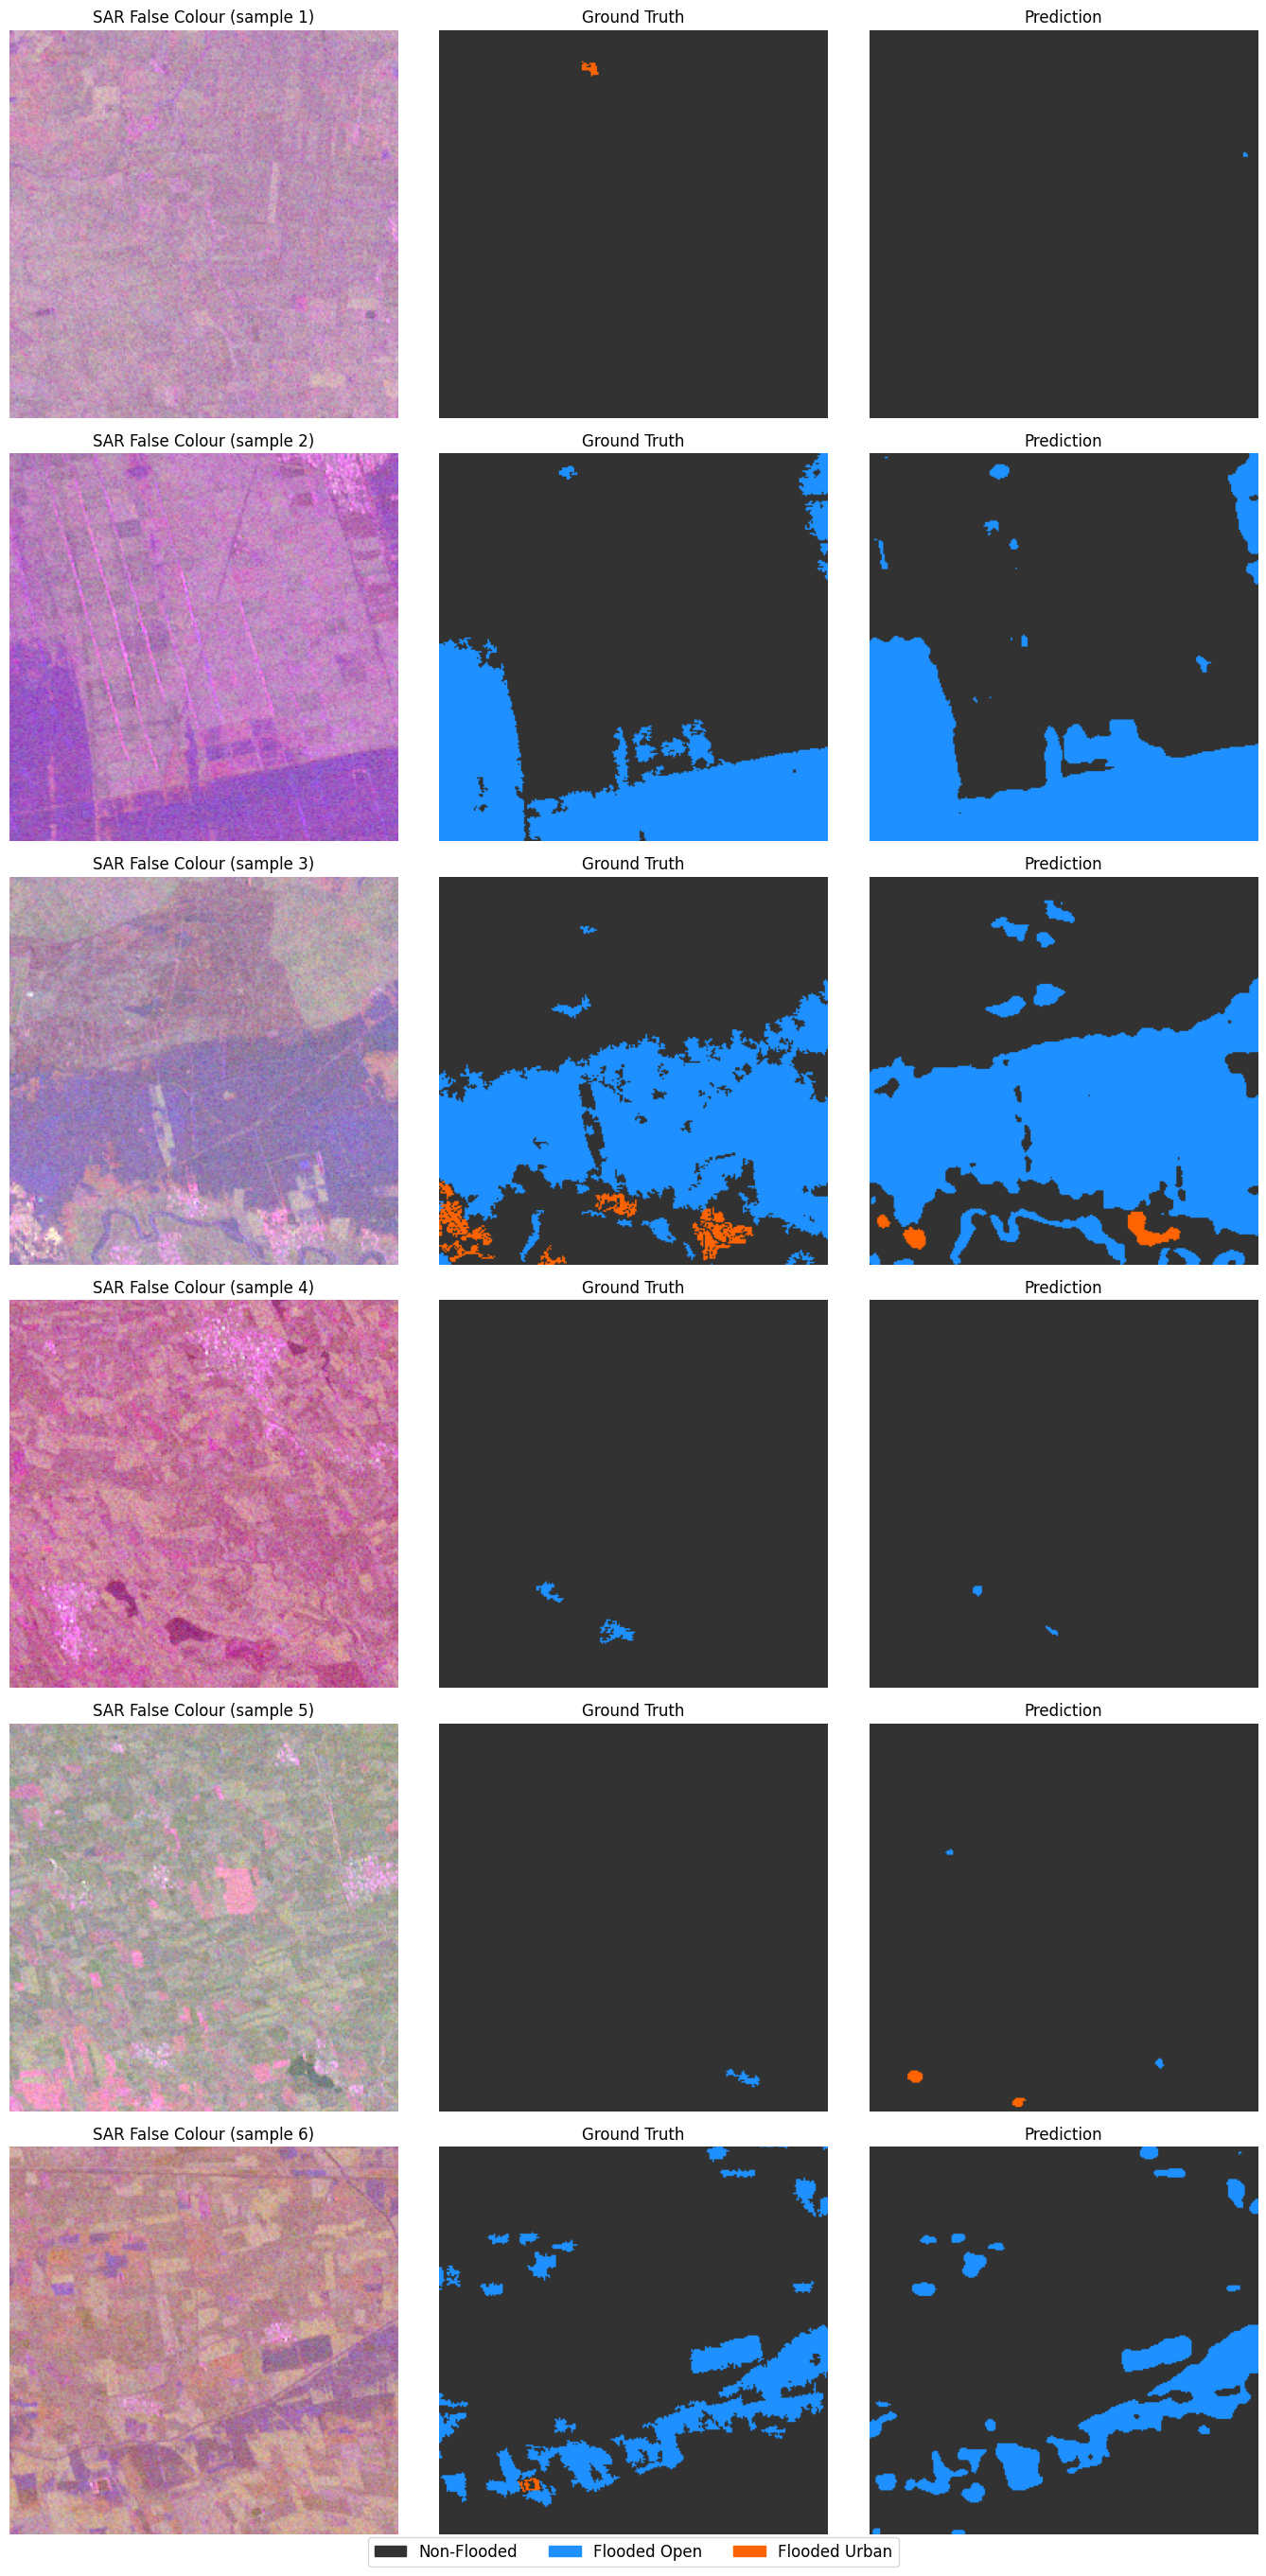

Saved → qualitative_results.png


In [ ]:
def mask_to_rgb(mask_np, palette):
    out = np.zeros((*mask_np.shape, 3), dtype=np.uint8)
    for cls, colour in enumerate(palette):
        out[mask_np == cls] = colour
    return out

def sar_false_colour(img_tensor):
    img_np = img_tensor.cpu().numpy()
    r = img_np[7]; g = img_np[6]; b = img_np[5]
    return np.stack([r, g, b], axis=-1).clip(0, 1)

viz_imgs, viz_masks = next(iter(val_loader))
viz_imgs = viz_imgs.to(device)

with torch.no_grad():
    if scaler is not None:
        with torch.amp.autocast('cuda'):
            viz_logits = model(viz_imgs)
    else:
        viz_logits = model(viz_imgs)

viz_preds = torch.argmax(viz_logits, dim=1).cpu().numpy()
viz_masks_np = viz_masks.numpy()

n_show = min(6, len(viz_imgs))
fig, axes = plt.subplots(n_show, 3, figsize=(14, n_show * 4.5))

for i in range(n_show):
    sar_rgb  = sar_false_colour(viz_imgs[i].cpu())
    gt_rgb   = mask_to_rgb(viz_masks_np[i], PALETTE) / 255.0
    pred_rgb = mask_to_rgb(viz_preds[i],    PALETTE) / 255.0

    axes[i, 0].imshow(sar_rgb)
    axes[i, 0].set_title(f'SAR False Colour (sample {i+1})')
    axes[i, 1].imshow(gt_rgb)
    axes[i, 1].set_title('Ground Truth')
    axes[i, 2].imshow(pred_rgb)
    axes[i, 2].set_title('Prediction')
    for ax in axes[i]: ax.axis('off')

# Legend
patches = [mpatches.Patch(color=[c/255 for c in col], label=name)
           for col, name in zip(PALETTE, classes_name)]
fig.legend(handles=patches, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.01), fontsize=12)

plt.tight_layout()
plt.savefig('qualitative_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → qualitative_results.png')

## <span style="color:#3498DB;">12. Summary</span>

In [18]:
print('╔' + '═'*62 + '╗')
print('║  Physics-Guided UNet++ — Final Evaluation Summary         ║')
print('╠' + '═'*62 + '╣')
print(f'║  Encoder       : EfficientNet-B4 (ImageNet pretrained)    ║')
print(f'║  Decoder       : UNet++ + SCSE attention                  ║')
print(f'║  Loss          : WCE + {lambda_dice}·Dice + (0→{lambda_phys_max})·Physics         ║')
print(f'║  Epochs        : {epochs:<44} ║')
print('╠' + '═'*62 + '╣')
print(f'║  mIoU          : {final_miou:.4f}                                   ║')
print(f'║  mF1           : {final_mf1:.4f}                                   ║')
print('╠' + '═'*62 + '╣')
for i, name in enumerate(classes_name):
    print(f'║  {name:<14}  IoU={final_ious[i]:.4f}   F1={final_f1s[i]:.4f}           ║')
print('╠' + '═'*62 + '╣')
print(f'║  Best Urban F1 checkpoint : {ckpt_urban:<34}║')
print(f'║  Best Val Loss checkpoint : {ckpt_loss:<34}║')
print('╚' + '═'*62 + '╝')

╔══════════════════════════════════════════════════════════════╗
║  Physics-Guided UNet++ — Final Evaluation Summary         ║
╠══════════════════════════════════════════════════════════════╣
║  Encoder       : EfficientNet-B4 (ImageNet pretrained)    ║
║  Decoder       : UNet++ + SCSE attention                  ║
║  Loss          : WCE + 0.5·Dice + (0→0.8)·Physics         ║
║  Epochs        : 50                                           ║
╠══════════════════════════════════════════════════════════════╣
║  mIoU          : 0.4105                                   ║
║  mF1           : 0.4412                                   ║
╠══════════════════════════════════════════════════════════════╣
║  Non-Flooded     IoU=0.9886   F1=0.9941           ║
║  Flooded Open    IoU=0.1874   F1=0.2430           ║
║  Flooded Urban   IoU=0.0556   F1=0.0864           ║
╠══════════════════════════════════════════════════════════════╣
║  Best Urban F1 checkpoint : best_urban_f1.pth                 ║
║  Best V